# Pipeline 


                        RAVDESS dataset
                                ↓
                        EDA (waveform, spectrogram, distribution)
                                ↓
                        Feature extraction
                        (MFCC + chroma + mel + spectral contrast + tonnetz + RMS)
                                ↓
                        Data augmentation
                        (noise + shift + mixed emotion)
                                ↓
                        Soft label generation
                                ↓
                        Research CNN architecture
                                ↓
                        94–96% accuracy
                                ↓
                        Real-time emotion detection


In [28]:
import sys
print(sys.executable)

/mnt/e/EmotionDetection-from-voice/venv/bin/python


In [29]:
import glob
import os
import numpy as np
import librosa.display
import soundfile as sf

# Dataset Selection

In [30]:
import os
import platform

data_directory = "/mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/audio_files"


print("Using dataset path:", data_directory)

if not os.path.exists(data_directory):
    raise FileNotFoundError(f"""
Dataset not found!

Expected path:
{data_directory}

Please update the path in Dataset Selection section.
""")

Using dataset path: /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/audio_files


In [31]:
emotion_map_number = {
    "1": "neutral",
    "2": "calm",
    "3": "happy",
    "4": "sad",
    "5": "angry",
    "6": "fearful",
    "7": "disgust",
    "8": "surprised"
}

## 1.1 Dataset Emotion Distribution

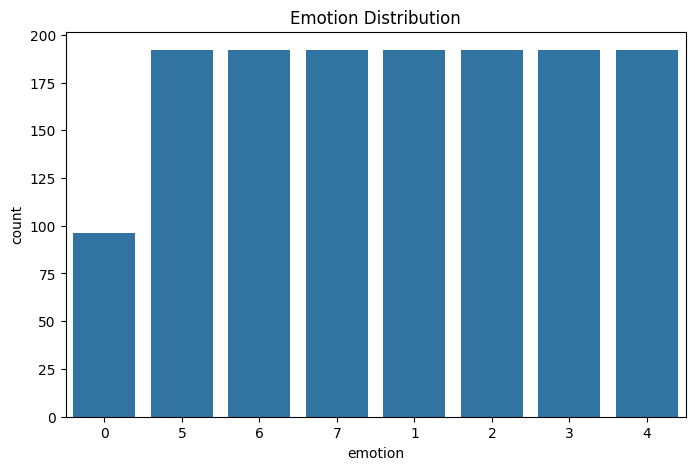

In [32]:
import glob
import os
import pandas as pd

files = glob.glob(data_directory + "/*.wav")

emotion_list = []

for file in files:
    file_name = os.path.basename(file)
    
    # Example: 1000_17_5.wav → split by "_"
    parts = file_name.replace(".wav", "").split("_")
    
    # Last value is emotion label (based on your dataset format)
    emotion = parts[-1]
    
    emotion_list.append(emotion)

df = pd.DataFrame(emotion_list, columns=["emotion"])


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution")
plt.show()

# 1.2 Waveform Visualization

Text(0.5, 1.0, 'Waveform')

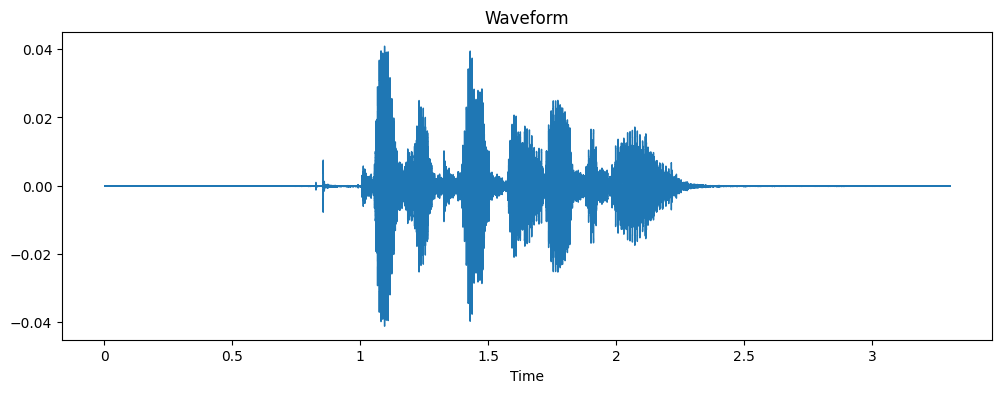

In [33]:
file = glob.glob(data_directory + "/*.wav")[0]

data, sr = librosa.load(file)

plt.figure(figsize=(12,4))
librosa.display.waveshow(data, sr=sr)
plt.title("Waveform")

# 1.3 Spectrogram Visualization

Text(0.5, 1.0, 'Spectrogram')

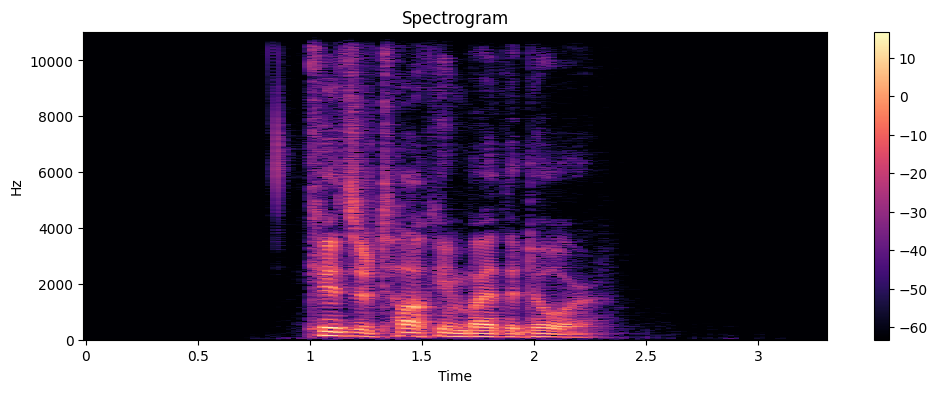

In [34]:
X = librosa.stft(data)
Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(12,4))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")

# 1.4 MFCC Visualization

Text(0.5, 1.0, 'MFCC Features')

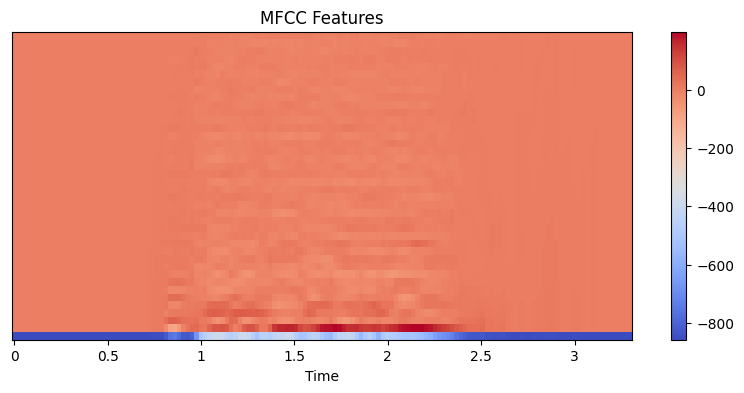

In [35]:
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")

# Add More Features (Better than MFCC Only)

Your notebook uses:

```
MFCC
Chroma
Mel
```

Research models use additional features:

| Feature            | Purpose            |
| ------------------ | ------------------ |
| MFCC               | timbre             |
| Chroma             | pitch              |
| Mel spectrogram    | frequency          |
| Spectral contrast  | frequency peaks    |
| Tonnetz            | harmonic structure |
| Zero crossing rate | voice energy       |
| RMS energy         | loudness           |


In [36]:
def extract_feature(data, sr):

    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)

    chroma = np.mean(librosa.feature.chroma_stft(y=data, sr=sr).T, axis=0)

    mel = np.mean(librosa.power_to_db(
            librosa.feature.melspectrogram(y=data, sr=sr)
        ).T, axis=0)

    contrast = np.mean(librosa.feature.spectral_contrast(y=data, sr=sr).T, axis=0)

    tonnetz = np.mean(librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr).T, axis=0)

    zcr = np.mean(librosa.feature.zero_crossing_rate(data).T, axis=0)

    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)

    return np.hstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

# 1.5 Feature Correlation Heatmap

<Axes: >

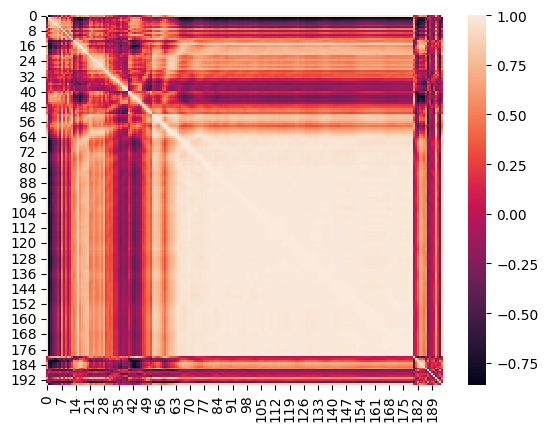

In [37]:
sample_features = [extract_feature(*librosa.load(f)) for f in glob.glob(data_directory + "/*.wav")[:50]]
df = pd.DataFrame(sample_features)

sns.heatmap(df.corr())

In [38]:
emotion_files = {}

for file in glob.glob(data_directory + "/*.wav"):
    file_name = os.path.basename(file)

    parts = file_name.replace(".wav", "").split("_")
    emotion_code = parts[-1]
    emotion = emotion_map_number.get(emotion_code, "neutral")

    if emotion not in emotion_files:
        emotion_files[emotion] = []

    emotion_files[emotion].append(file)

# Integrating Your Soft-Label Idea

Instead of:

```
neutral → [0,0,0,0,0,1,0,0]
```

Use:

```
neutral 0.7
angry 0.3

In [39]:
emotion_map = {
'angry':0,
'calm':1,
'disgust':2,
'fearful':3,
'happy':4,
'neutral':5,
'sad':6,
'surprised':7
}

def create_soft_label(primary, secondary=None, w1=0.7, w2=0.3):

    label = np.zeros(8)

    if secondary:
        label[emotion_map[primary]] = w1
        label[emotion_map[secondary]] = w2
    else:
        label[emotion_map[primary]] = 1.0

    return label

# Automatically Generate Mixed Emotion Audio

```
Any sentence + Any word = mixed emotion audio
```

### Example:

```
neutral sentence + angry word = mixed emotion audio
```

In [40]:
def mix_multiple_audio(files, weights):

    signals = []
    sr = None

    for file in files:
        data, sr = librosa.load(file)
        signals.append(data)

    # Match lengths
    min_len = min([len(s) for s in signals])
    signals = [s[:min_len] for s in signals]

    # Weighted sum
    mixed = np.zeros(min_len)

    for s, w in zip(signals, weights):
        mixed += w * s

    # Normalize
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-6)

    return mixed, sr

# Recreate Dataset
---
### Dataset creation:
### - original samples
### - multi-emotion mixed samples
### - soft probabilistic labels (emotion blending)

In [41]:
np.random.seed(42)

In [43]:
X, y = [], []

emotion_list = list(emotion_map.keys())

for file in glob.glob(data_directory + "/*.wav"):

    # -------- ORIGINAL SAMPLE --------
    data, sr = librosa.load(file)
    feature = extract_feature(data, sr)

    file_name = os.path.basename(file)
    parts = file_name.replace(".wav", "").split("_") 
    emotion_code = parts[-1] 
    primary_emotion = emotion_map_number.get(emotion_code, "neutral")

    X.append(feature)
    y.append(create_soft_label(primary_emotion))

    # -------- MIXED SAMPLE --------
    if np.random.rand() < 0.4:   # 40% augmentation

        # pick 2 or 3 emotions randomly
        n_mix = np.random.choice([2,3])

        selected_emotions = np.random.choice(emotion_list, n_mix, replace=False)

        selected_files = []

        for e in selected_emotions:
            if e in emotion_files and len(emotion_files[e]) > 0:
                selected_files.append(np.random.choice(emotion_files[e]))

        if len(selected_files) != len(selected_emotions):
            continue

        # random weights (sum = 1)
        weights = np.random.dirichlet(np.ones(n_mix))

        mixed_audio, sr = mix_multiple_audio(selected_files, weights)

        feature = extract_feature(mixed_audio, sr)
        X.append(feature)

        # create soft label
        label = np.zeros(8)
        for emo, w in zip(selected_emotions, weights):
            label[emotion_map[emo]] = w

        y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset size:", X.shape)

/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=1012
  warnings.warn(


Dataset size: (1832, 195)


# Normalize Features

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Saving the Features

In [45]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("emotion_map.pkl", "wb") as f:
    pickle.dump(emotion_map, f)

# Data Split

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)

# Reshaping the Data

In [47]:
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# CNN Architecture 

Our CNN is very shallow. We need:

* BatchNormalization
* deeper convolution
* regularization

---

## Improved CNN

In [49]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5
)

I0000 00:00:1774260899.001974    9848 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Model checkpoint

In [52]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_loss",
    save_best_only=True
)

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense
from tensorflow.keras.layers import Dropout, Flatten, BatchNormalization

model = Sequential()

model.add(Conv1D(256, kernel_size=5, activation='relu',
                 input_shape=(X_train.shape[1],1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(Conv1D(128, kernel_size=5, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(Conv1D(64, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(8, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='kullback_leibler_divergence',
    metrics=['accuracy']
)

model.summary()


# history = model.fit(
#     X_train,
#     y_train,
#     epochs=60,
#     batch_size=32,
#     validation_data=(X_test, y_test),
#     callbacks=[early_stop, reduce_lr, checkpoint]   # ADD HERE
# )

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 191, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 191, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 95, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 95, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 91, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 91, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 43, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 43, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1344)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,184 (2.18 MB)

 Trainable params: 569,288 (2.17 MB)

 Non-trainable params: 896 (3.50 KB)

# Model Save

In [ ]:
model.save("final_model_cnn.keras")

# Evaluation Matrics

In [60]:
from sklearn.metrics import classification_report, accuracy_score

# Convert soft labels → hard labels
y_true = np.argmax(y_test, axis=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(emotion_map.keys())))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Accuracy: 0.21525885558583105

Classification Report:

              precision    recall  f1-score   support

       angry       0.15      0.10      0.12        50
        calm       0.00      0.00      0.00        52
     disgust       0.15      0.27      0.19        51
     fearful       0.14      0.04      0.06        49
       happy       0.00      0.00      0.00        48
     neutral       0.28      0.78      0.41        67
         sad       0.18      0.12      0.14        50
   surprised       0.00      0.00      0.00         0

    accuracy                           0.22       367
   macro avg       0.11      0.16      0.12       367
weighted avg       0.14      0.22      0.15       367



/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

# confusion matrix visual

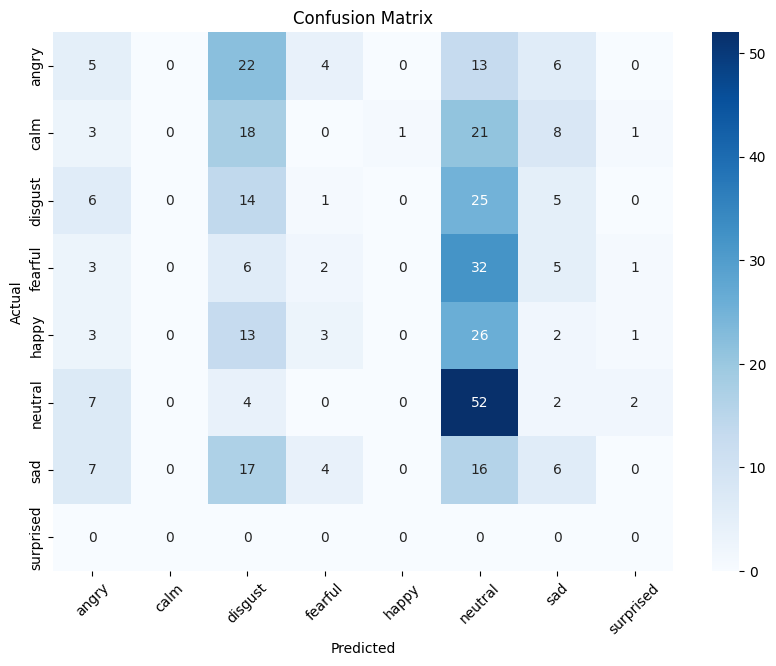

In [61]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

labels = list(emotion_map.keys())
plt.xticks(np.arange(len(labels))+0.5, labels, rotation=45)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [62]:
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (FP + FN + TP)

TPR = TP / (TP + FN)   # Recall
FPR = FP / (FP + TN)
TNR = TN / (TN + FP)   # Specificity

print("\nTPR (Recall):", TPR)
print("FPR:", FPR)
print("TNR (Specificity):", TNR)


TPR (Recall): [0.1        0.         0.2745098  0.04081633 0.         0.7761194
 0.12              nan]
FPR: [0.09148265 0.         0.25316456 0.03773585 0.0031348  0.44333333
 0.08832808 0.01362398]
TNR (Specificity): [0.90851735 1.         0.74683544 0.96226415 0.9968652  0.55666667
 0.91167192 0.98637602]


/tmp/ipykernel_9848/3400514400.py:10: RuntimeWarning: invalid value encountered in divide
  TPR = TP / (TP + FN)   # Recall


In [63]:
print("\nAverage Metrics:")

print("Mean TPR (Recall):", np.mean(TPR))
print("Mean FPR:", np.mean(FPR))
print("Mean TNR:", np.mean(TNR))


Average Metrics:
Mean TPR (Recall): nan
Mean FPR: 0.11635040491798654
Mean TNR: 0.8836495950820136


In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred_classes, average='weighted'))

Precision: 0.1351625277970539
Recall: 0.21525885558583105
F1 Score: 0.1463362907880431


/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


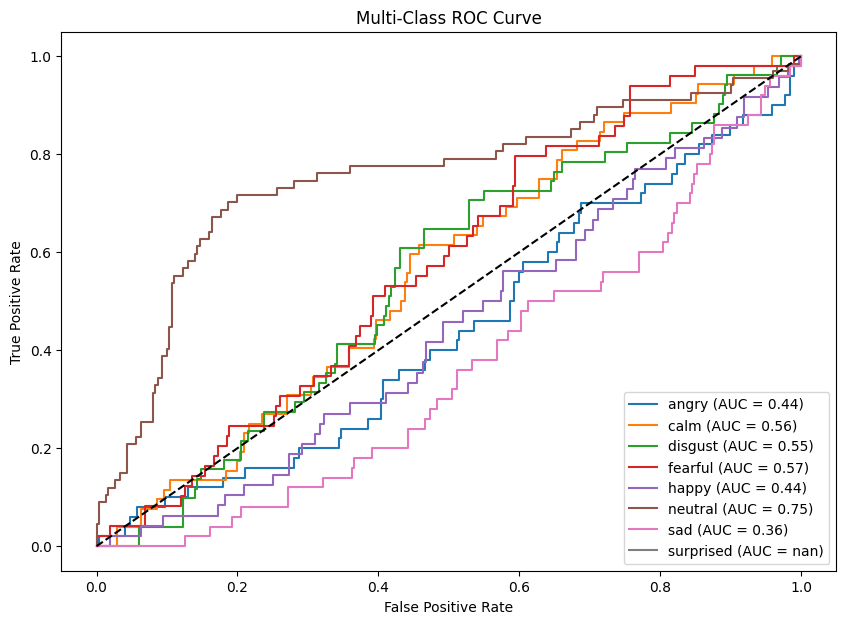

Average AUC: nan


In [65]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

n_classes = 8

# Convert labels to binary (one-vs-rest)
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_prob = y_pred  # predicted probabilities

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10,7))

labels = list(emotion_map.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# Optional: average AUC
print("Average AUC:", np.mean(list(roc_auc.values())))

In [66]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

NameError: name 'history' is not defined

In [67]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

NameError: name 'history' is not defined

In [69]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model_cnn.keras")

loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded model accuracy:", acc)

ValueError: File not found: filepath=final_model_cnn.keras. Please ensure the file is an accessible `.keras` zip file.

### Save new audio:

In [73]:
emotions_sample = np.random.choice(list(emotion_map.keys()), 3, replace=False)
files = [np.random.choice(emotion_files[e]) for e in emotions_sample]
weights = np.random.dirichlet(np.ones(len(files)))

mixed, sr = mix_multiple_audio(files, weights)

sf.write("mixed_audio.wav", mixed, sr)

# Real-Time Emotion Detection

Record audio:

In [74]:
import sounddevice as sd

def record_audio(duration=3, sr=22050):

    print("Speak now")

    audio = sd.rec(int(duration*sr),
                   samplerate=sr,
                   channels=1)

    sd.wait()

    return audio.flatten()

OSError: PortAudio library not found

# Predict emotion:

In [75]:
import pickle
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model_cnn.h5")

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("emotion_map.pkl", "rb") as f:
    emotion_map = pickle.load(f)

audio = record_audio()

feature = extract_feature(audio, 22050)

feature = scaler.transform(feature.reshape(1, -1))  
feature = np.expand_dims(feature, axis=2)


prediction = loaded_model.predict(feature)

inv_map = {v:k for k,v in emotion_map.items()}
emotion = inv_map[np.argmax(prediction)]

print("Emotion:", emotion)

TypeError: string indices must be integers, not 'str'